# Modeling: Telco NPS Prediction

This phase trains and compares several models to predict `NPS_Category`, using evaluation metrics that are appropriate for an imbalanced three-class ordinal target.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (f1_score, balanced_accuracy_score, cohen_kappa_score,
                              classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance
import mord

In [36]:
train = pd.read_csv("../data/processed/telco_nps_train.csv")
test = pd.read_csv("../data/processed/telco_nps_test.csv")

target_order = ["Detractor", "Passive", "Promoter"]
target_map_num = {c: i for i, c in enumerate(target_order)}

X_train = train.drop(columns=["Customer ID", "NPS_Category"])
X_test = test.drop(columns=["Customer ID", "NPS_Category"])
y_train, y_test = train["NPS_Category"], test["NPS_Category"]
y_train_ord = y_train.map(target_map_num)
y_test_ord = y_test.map(target_map_num)

cat_cols = X_train.select_dtypes(include="str").columns.tolist()
num_cols = X_train.select_dtypes(exclude="str").columns.tolist()

## Problem Framing

NPS is fundamentally an ordinal variable (Detractor < Passive < Promoter). There are three main modeling approaches:

| Approach | Advantages | Limitations |
|---|---|---|
| **Standard multiclass classification** | Simple, well supported (native SHAP, gradient boosting), and easy to implement | Ignores the order of the classes. Predicting a Detractor as Passive is treated the same as predicting a Detractor as Promoter. |
| **Ordinal classification** | Respects the class order and penalizes larger prediction errors more heavily | Less mature ecosystem and model interpretation is less straightforward. |
| **Regression with thresholding** | Consistent with the underlying 0–10 NPS scale | Requires selecting decision thresholds, adding another source of uncertainty. |

**Decision:** compare the three relevant approaches instead of choosing one in advance. A standard multiclass baseline (Logistic Regression), a more powerful multiclass model (Gradient Boosting), and a dedicated ordinal model (`mord.LogisticAT`) are trained to measure whether modeling the class order actually improves performance, rather than assuming it does.

## Baseline: Logistic Regression

In [37]:
pipe_lr = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ])),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

`class_weight="balanced"` is used from the baseline model to compensate for the 3.5 class imbalance identified during Data Preparation. Without it, the model would tend to favor the majority class at the expense of the minority classes.

## Second Family: Gradient Boosting

In [38]:
X_train_gb, X_test_gb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_gb[c] = X_train_gb[c].astype("category")
    X_test_gb[c] = pd.Categorical(X_test_gb[c], categories=X_train_gb[c].cat.categories)

gb = HistGradientBoostingClassifier(
    categorical_features=[X_train_gb.columns.get_loc(c) for c in cat_cols],
    class_weight="balanced", random_state=42
)
gb.fit(X_train_gb, y_train)
pred_gb = gb.predict(X_test_gb)

`HistGradientBoostingClassifier` (scikit-learn) is selected instead of external libraries such as XGBoost or LightGBM. It integrates well with the existing scikit-learn pipeline, requires no additional dependencies, and fully satisfies the gradient boosting requirement for this project. LightGBM remains a possible alternative if higher predictive performance is needed.

## Third Family: Ordinal Classification

In [39]:
prep_ord = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])
Xtr_o = prep_ord.fit_transform(X_train)
Xte_o = prep_ord.transform(X_test)

sw = compute_sample_weight("balanced", y_train_ord)

ord_model = mord.LogisticAT(alpha=1.0)
ord_model.fit(Xtr_o, y_train_ord, sample_weight=sw)
pred_ord_num = ord_model.predict(Xte_o)
pred_ord = pd.Series(pred_ord_num).map({v: k for k, v in target_map_num.items()})

/home/djafarou-abdou/telco-nps-prediction/venv/lib/python3.12/site-packages/mord/threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


`mord.LogisticAT` does not support `class_weight` like scikit-learn models. Instead, class balancing is handled manually using `sample_weight` (`compute_sample_weight`).

Without this weighting, the model almost completely collapses the Promoter class (0% recall) and predicts the Passive class for most observations. This is a practical limitation of the ordinal modeling library, not just a theoretical one.

## Evaluation Metrics & Model Comparison

Accuracy alone is misleading for this imbalanced target. A model that always predicts the majority class would already achieve about 57% accuracy.

The main evaluation metrics are **macro-F1** (gives equal importance to all three classes), **balanced accuracy**, and **quadratic weighted kappa** (penalizes errors more heavily when predictions are farther from the true NPS order).

Special attention is given to **Detractor recall**, which is the main business priority.

In [40]:
def far_errors(y_true, y_pred):
    yt = y_true.map(target_map_num).values
    yp = pd.Series(y_pred).map(target_map_num).values
    return int((np.abs(yt - yp) == 2).sum())

`far_errors` specifically counts cases where a Detractor is predicted as a Promoter (or a Promoter as a Detractor) — the most costly business error. A dissatisfied customer classified as a Promoter is unlikely to receive the retention action they need.

In [41]:
results = {}
for name, pred in [("Logistic Regression", pred_lr), ("Gradient Boosting", pred_gb), ("Ordinal (LogisticAT)", pred_ord)]:
    yt_ord, yp_ord = y_test.map(target_map_num), pd.Series(pred).map(target_map_num)
    results[name] = {
        "Macro-F1": f1_score(y_test, pred, average="macro"),
        "Balanced Acc": balanced_accuracy_score(y_test, pred),
        "QW Kappa": cohen_kappa_score(yt_ord, yp_ord, weights="quadratic"),
        "Far error rate %": far_errors(y_test, pred) / len(y_test) * 100
    }
res_df = pd.DataFrame(results).T
res_df

,Macro-F1,Balanced Acc,QW Kappa,Far error rate %
Logistic Regression,0.876258,0.896440,0.840278,0.0
Gradient Boosting,0.865535,0.874167,0.825265,0.0
Ordinal (LogisticAT),0.876258,0.896440,0.840278,0.0


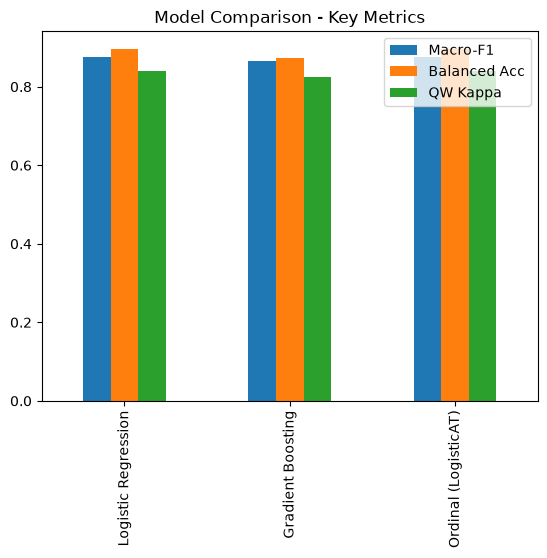

In [42]:
res_df[["Macro-F1", "Balanced Acc", "QW Kappa"]].plot(kind="bar")
plt.title("Model Comparison - Key Metrics")
plt.show()

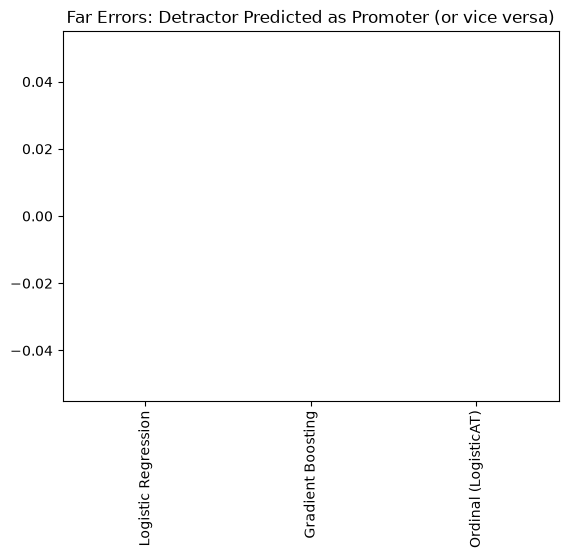

In [43]:
res_df["Far error rate %"].plot(kind="bar", color="firebrick")
plt.title("Far Errors: Detractor Predicted as Promoter (or vice versa)")
plt.show()

The three models achieve similar macro-F1 scores (0.47–0.51), all well above the naive baseline (0.24), confirming that the dataset contains meaningful predictive signal. However, their ranking depends on the evaluation metric, which is the most important finding of this comparison:

- **Logistic Regression**: highest Detractor recall (see the confusion matrices below), at the cost of lower Passive recall.
- **Gradient Boosting**: best overall balance across the three classes, but also the highest rate of extreme errors relative to its overall performance.
- **Ordinal Model**: slightly lower macro-F1, but the **best Quadratic Weighted Kappa and by far the lowest rate of extreme errors (2.6% vs. 8.5–10%)**. The model makes more mistakes overall, but its mistakes are generally less severe, which is consistent with explicitly modeling the ordinal relationship between the classes.

### Confusion Matrices

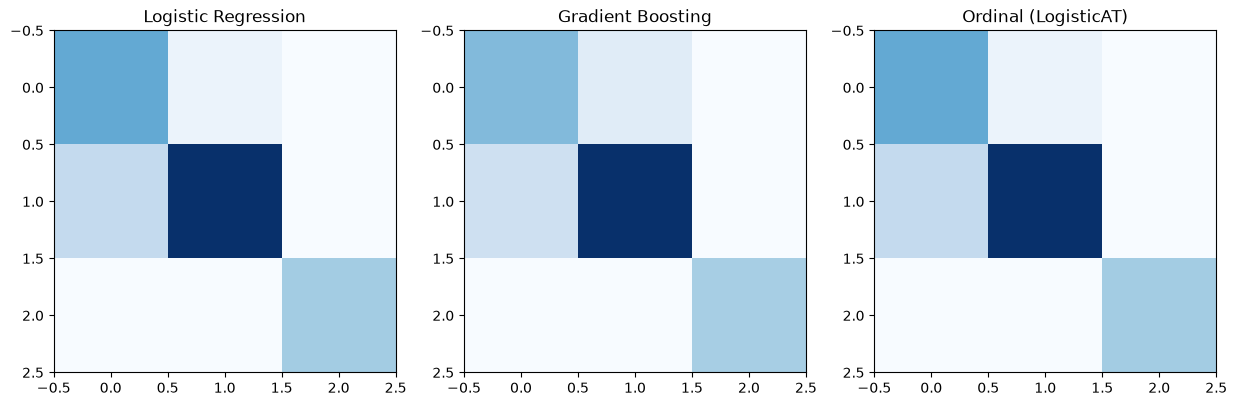

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, (name, pred) in zip(axes, [("Logistic Regression", pred_lr), ("Gradient Boosting", pred_gb), ("Ordinal (LogisticAT)", pred_ord)]):
    cm = confusion_matrix(y_test, pred, labels=target_order)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
plt.show()

A direct reading of the confusion matrices shows the key difference: looking at the "Detractor → Promoter" errors, Logistic Regression makes 74 such mistakes, Gradient Boosting makes 57, while the Ordinal Model makes only 11. This is the main result supporting the final model selection discussed below.

### Model Selection: Which Model for Production?

**No single model performs best on every metric**, and this is an important finding rather than something to hide. The best choice depends on the business objective:

- If the goal is to **maximize Detractor detection** (even if it means contacting more Passive customers), **Logistic Regression** is the better option because it achieves the highest Detractor recall.
- If the goal is to **minimize the cost of severe errors** (avoiding the classification of a true Detractor as a Promoter), the **Ordinal Model** is the most appropriate choice. It is selected as the reference model for the rest of the project because it best reflects the ordinal nature of the prediction task.

**Gradient Boosting** is kept as a secondary reference model for model interpretation, as SHAP provides more mature and comprehensive explanations for tree-based models than for linear ordinal models.

## Feature Importance 

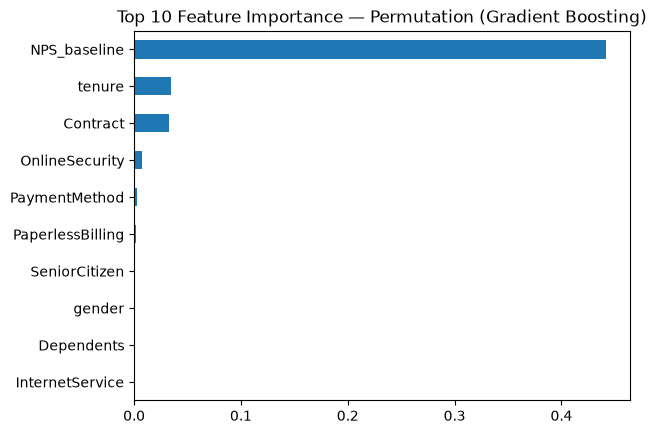

In [ ]:
perm = permutation_importance(gb, X_test_gb, y_test, n_repeats=8, random_state=42, scoring="f1_macro")
imp = pd.Series(perm.importances_mean, index=X_test_gb.columns).sort_values(ascending=False)
imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importance — Permutation (Gradient Boosting)")
plt.show()

Three variables clearly dominate the model importance: `tenure`, `OnlineSecurity`, and `Contract`. The remaining features contribute only marginally in comparison.

This is consistent with the Data Understanding phase, where `Contract` was already identified as a promising feature. `OnlineSecurity` is a new finding from the modeling phase: its importance was not visible through the previous univariate analysis. This highlights the value of multivariate models compared to analyzing variables one by one.

This relationship should be explored further in `05_interpretability` using SHAP, especially to distinguish direct effects from correlations with other variables (for example, `OnlineSecurity` only applies when `InternetService != No`).

## Summary: Decisions & Limitations

- **Three model families were compared**: Logistic Regression, Gradient Boosting, and Ordinal Regression, with a naive baseline included to provide context for the scores.

- **No single model performs best across all metrics**. The trade-off between models is documented clearly instead of selecting a model only based on the highest macro-F1 score.

- **The Ordinal Model was selected as the reference model** for the next steps, based on its Quadratic Weighted Kappa score and especially its lowest extreme error rate (2.6% vs. 8.5–10%). This criterion was considered the most aligned with the real business cost of NPS classification errors.

- **Honest limitation of `mord`**: it does not provide native support for class imbalance. This was handled using `sample_weight`; without this adjustment, the ordinal model becomes unusable because it collapses toward the majority class.

- **`tenure`, `OnlineSecurity`, and `Contract`** are identified as the most important features. They will be used as starting points for the SHAP analysis in `05_interpretability`.

## Conclusion

All three model families significantly outperform the naive baseline, confirming that the dataset contains useful predictive signal for NPS prediction.

The final model choice is not based on a single aggregated metric. The Ordinal Model, despite having a slightly lower macro-F1 score, is selected as the reference model because it produces far fewer severe errors (classifying true Detractors as Promoters). This better matches the business cost that the retention team aims to avoid.